In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('AAPL_cleaned.csv')

df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
1,2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2,2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
3,2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
4,2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1258, 6)

Columns:
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

Missing Values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [4]:
print(df.dtypes)

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


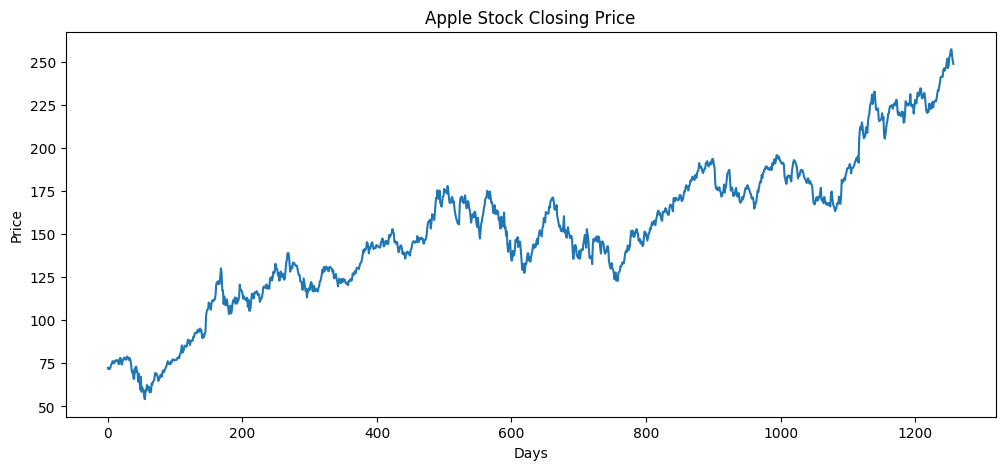

In [5]:
plt.figure(figsize=(12,5))

plt.plot(df['Close'])

plt.title("Apple Stock Closing Price")

plt.xlabel("Days")

plt.ylabel("Price")

plt.show()

In [6]:
X = df[['Open','High','Low','Volume']]

y = df['Close']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1006, 4)
(252, 4)


In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [9]:
predictions = model.predict(X_test)

print(predictions[:10])

[169.21618447  77.80382331  59.74103478  58.32091614 167.88030895
 151.02370426 146.49520354 179.35552657 223.21259962 180.75457184]


In [10]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Mean Squared Error: 0.9964425595345666
R2 Score: 0.9994242482306787


In [11]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

comparison.head(10)

,Actual,Predicted
0,170.394104,169.216184
1,77.034630,77.803823
2,61.041286,59.741035
3,59.126949,58.320916
4,167.985016,167.880309
5,151.420303,151.023704
6,145.673447,146.495204
7,179.618362,179.355527
8,222.383621,223.212600
9,182.034088,180.754572


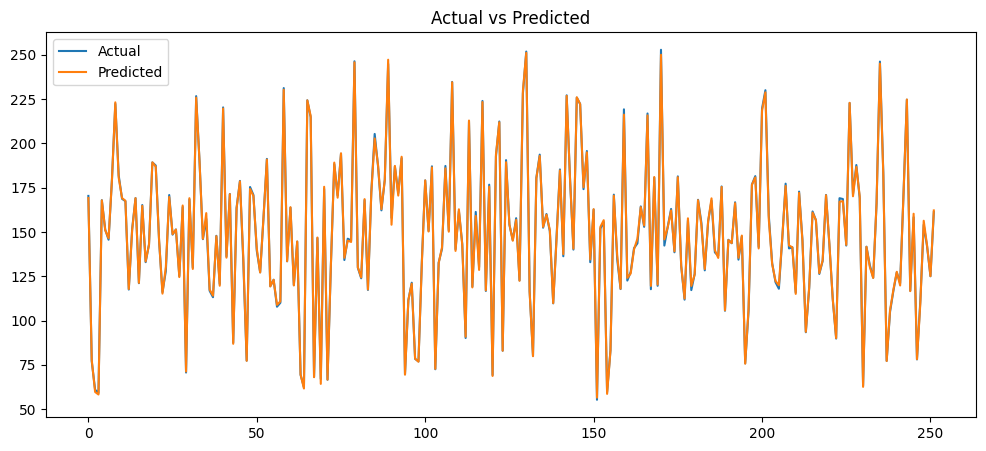

In [12]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label='Actual')

plt.plot(predictions, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted")

plt.show()